# Entrainement d'un modele CNN (ResNet18) - Transfer Learning
Dans ce notebook j'entraine un ResNet18 pre-entraine sur le dataset de classification de dechets.

In [1]:
# J'importe toutes les bibliotheques necessaires
import os
import json
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Je definis le dossier racine du projet
base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f"Base dir: {base_dir}")
print(f"CUDA disponible : {torch.cuda.is_available()}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilise : {device}")

Base dir: D:\_Projet Vision Artificielle
CUDA disponible : False
Device utilise : cpu


## 2. Chargement et preparation des donnees

In [2]:
# Je charge les metadonnees du dataset equilibre
meta_path = os.path.join(base_dir, 'donnees', 'metadata_equilibre.parquet')
print(f"Chargement de : {meta_path}")

if not os.path.exists(meta_path):
    raise FileNotFoundError(f"Fichier metadonnees manquant : {meta_path}")

meta = pd.read_parquet(meta_path)
print(f"Total lignes (avec oversampling) : {len(meta)}")

# Je corrige les chemins car les images sont stockees dans images_pretraitees/{split}/{etiquette}/{fichier}
def fix_image_path(row):
    filename = os.path.basename(str(row['chemin_fichier']))
    etiquette = row['etiquette']
    split = row['split']
    candidate = os.path.join(base_dir, 'donnees', 'images_pretraitees', split, etiquette, filename)
    if os.path.exists(candidate):
        return candidate
    for s in ['train', 'val', 'test']:
        c = os.path.join(base_dir, 'donnees', 'images_pretraitees', s, etiquette, filename)
        if os.path.exists(c):
            return c
    return None

meta['chemin_fichier'] = meta.apply(fix_image_path, axis=1)

# Je supprime les entrees dont le chemin n'a pas pu etre resolu
meta_valid = meta[meta['chemin_fichier'].notna()].copy()
missing = len(meta) - len(meta_valid)
if missing > 0:
    print(f"{missing} chemins non resolus (images oversamplees sans copie sur disque)")
    meta = meta_valid
else:
    print(f"Tous les chemins sont resolus ({len(meta)} lignes)")

print(f"\nRepartition par split :")
print(meta['split'].value_counts())
print(f"\nRepartition par classe :")
print(meta['etiquette'].value_counts())

Chargement de : D:\_Projet Vision Artificielle\donnees\metadata_equilibre.parquet
Total lignes (avec oversampling) : 3254
Tous les chemins sont resolus (3254 lignes)

Repartition par split :
split
train    2496
test      380
val       378
Name: count, dtype: int64

Repartition par classe :
etiquette
paper        594
glass        567
plastic      561
metal        538
cardboard    537
trash        457
Name: count, dtype: int64


In [3]:
# J'encode les etiquettes en valeurs numeriques
le = LabelEncoder()
meta['label_enc'] = le.fit_transform(meta['etiquette'])

print(f"Classes : {le.classes_.tolist()}")
print(f"Nombre de classes : {len(le.classes_)}")

Classes : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Nombre de classes : 6


In [4]:
# Je definis les transformations pour le train (avec augmentation) et pour val/test
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Transformations definies.")

Transformations definies.


In [5]:
# Je cree un Dataset PyTorch personnalise pour charger les images depuis le disque
class ImageDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'chemin_fichier']
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Image non trouvee : {img_path}")
        img = Image.open(img_path).convert('RGB')
        img = self.transform(img)
        label = self.df.loc[idx, 'label_enc']
        return img, label

print("Dataset defini.")

Dataset defini.


In [6]:
# Je separe les donnees par split et je cree les DataLoaders
train_df = meta[meta['split'] == 'train']
val_df   = meta[meta['split'] == 'val']
test_df  = meta[meta['split'] == 'test']

print(f"Train : {len(train_df)} images | Val : {len(val_df)} images | Test : {len(test_df)} images")

batch_size = 32 if torch.cuda.is_available() else 16

train_ds = ImageDataset(train_df, transform_train)
val_ds   = ImageDataset(val_df,   transform_val)
test_ds  = ImageDataset(test_df,  transform_val)

# num_workers=0 pour la compatibilite Windows
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Batch size : {batch_size}")
print(f"Batches - Train : {len(train_loader)} | Val : {len(val_loader)} | Test : {len(test_loader)}")

Train : 2496 images | Val : 378 images | Test : 380 images
Batch size : 16
Batches - Train : 156 | Val : 24 | Test : 24


## 3. Architecture du modele (ResNet18 + Transfer Learning)

In [7]:
# Je charge ResNet18 pre-entraine sur ImageNet et j'adapte la derniere couche au nombre de classes
print("Chargement de ResNet18 pre-entraine...")
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(le.classes_))
model = model.to(device)

print(f"Modele charge sur {device} | Nombre de classes : {len(le.classes_)}")

Chargement de ResNet18 pre-entraine...
Modele charge sur cpu | Nombre de classes : 6


## 4. Optimiseur et fonction de cout

In [8]:
# Je definis la fonction de cout, l'optimiseur et le scheduler de taux d'apprentissage
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print("Optimiseur : AdamW | Fonction de cout : CrossEntropyLoss | Scheduler : StepLR")

Optimiseur : AdamW | Fonction de cout : CrossEntropyLoss | Scheduler : StepLR


## 5. Boucle d'entrainement

In [9]:
# J'entraine le modele pendant 10 epochs avec arret precoce si aucune amelioration
num_epochs = 10
best_val_acc = 0.0
best_model_path = os.path.join(base_dir, 'modeles', 'best_cnn_model.pth')
patience = 3
patience_counter = 0

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    # Phase d'entrainement
    model.train()
    running_loss, running_corrects, total = 0.0, 0, 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=True)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data).item()
        total += labels.size(0)
        pbar.set_postfix({'loss': f'{running_loss/total:.4f}', 'acc': f'{running_corrects/total:.4f}'})

    epoch_loss = running_loss / total
    epoch_acc  = running_corrects / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    # Phase de validation
    model.eval()
    val_loss, val_corrects, val_total = 0.0, 0, 0
    with torch.no_grad():
        pbar_val = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=True)
        for inputs, labels in pbar_val:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data).item()
            val_total += labels.size(0)

    val_epoch_loss = val_loss / val_total
    val_epoch_acc  = val_corrects / val_total
    val_losses.append(val_epoch_loss)
    val_accuracies.append(val_epoch_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss : {epoch_loss:.4f} Acc : {epoch_acc:.4f} | Val Loss : {val_epoch_loss:.4f} Acc : {val_epoch_acc:.4f}")

    # Je sauvegarde le modele si la precision de validation s'ameliore
    if val_epoch_acc > best_val_acc:
        best_val_acc = val_epoch_acc
        patience_counter = 0
        os.makedirs(os.path.dirname(best_model_path), exist_ok=True)
        torch.save(model.state_dict(), best_model_path)
        print(f"  Meilleur modele sauvegarde (Val Acc : {val_epoch_acc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"  Arret precoce : aucune amelioration depuis {patience} epochs.")
            break

    scheduler.step()

print(f"\nEntrainement termine. Meilleur modele sauvegarde dans : {best_model_path}")

Epoch 1/10 [Train]:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 1/10 [Train]:   0%|          | 0/156 [00:00<?, ?it/s, loss=1.9945, acc=0.1250]

Epoch 1/10 [Train]:   1%|          | 1/156 [00:00<02:25,  1.06it/s, loss=1.9945, acc=0.1250]

Epoch 1/10 [Train]:   1%|          | 1/156 [00:01<02:25,  1.06it/s, loss=1.9247, acc=0.1250]

Epoch 1/10 [Train]:   1%|▏         | 2/156 [00:01<02:28,  1.04it/s, loss=1.9247, acc=0.1250]

...

Epoch 7/10 [Val]:  92%|█████████▏| 22/24 [00:13<00:01,  1.70it/s]

Epoch 7/10 [Val]:  96%|█████████▌| 23/24 [00:13<00:00,  1.67it/s]

Epoch 7/10 [Val]: 100%|██████████| 24/24 [00:14<00:00,  1.86it/s]

Epoch 7/10 [Val]: 100%|██████████| 24/24 [00:14<00:00,  1.70it/s]

Epoch 7/10 | Train Loss : 0.0324 Acc : 0.9908 | Val Loss : 0.4592 Acc : 0.8730
  Arret precoce : aucune amelioration depuis 3 epochs.

Entrainement termine. Meilleur modele sauvegarde dans : D:\_Projet Vision Artificielle\modeles\best_cnn_model.pth


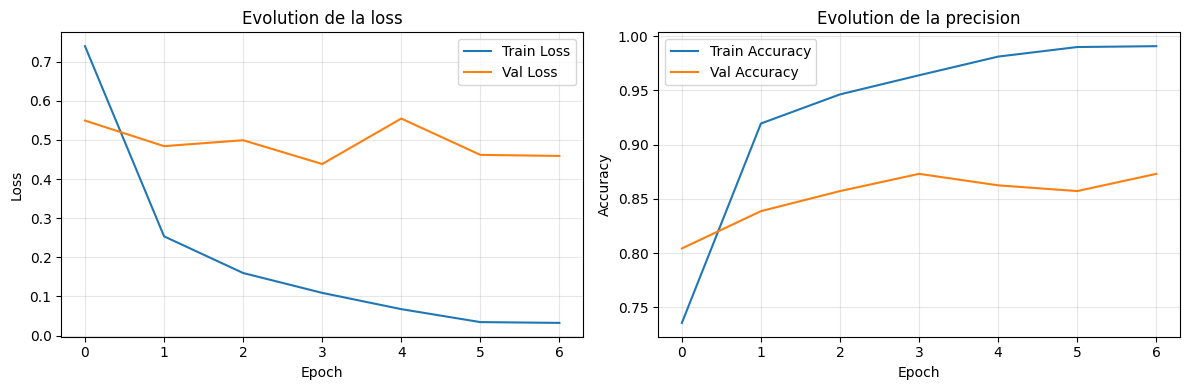

In [10]:
# J'affiche les courbes de loss et d'accuracy pour analyser l'entrainement
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Evolution de la loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies,   label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Evolution de la precision')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Evaluation sur le jeu de test

In [11]:
# Je charge le meilleur modele sauvegarde et je l'evalue sur le jeu de test
print(f"Chargement du meilleur modele : {best_model_path}")
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

test_loss, test_corrects, test_total = 0.0, 0, 0
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Evaluation test"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)
        test_loss += loss.item() * inputs.size(0)
        test_corrects += torch.sum(preds == labels.data).item()
        test_total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss /= test_total
test_acc   = test_corrects / test_total

print(f"\nTest Loss : {test_loss:.4f} | Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print("\nRapport de classification :")
print(classification_report(all_labels, all_preds, target_names=le.classes_, digits=4))

Chargement du meilleur modele : D:\_Projet Vision Artificielle\modeles\best_cnn_model.pth


Evaluation test:   0%|          | 0/24 [00:00<?, ?it/s]

Evaluation test:   4%|▍         | 1/24 [00:00<00:11,  1.92it/s]

Evaluation test:   8%|▊         | 2/24 [00:01<00:12,  1.77it/s]

Evaluation test:  12%|█▎        | 3/24 [00:01<00:13,  1.58it/s]

...

Evaluation test:  92%|█████████▏| 22/24 [00:12<00:01,  1.72it/s]

Evaluation test:  96%|█████████▌| 23/24 [00:13<00:00,  1.71it/s]

Evaluation test: 100%|██████████| 24/24 [00:14<00:00,  1.79it/s]

Evaluation test: 100%|██████████| 24/24 [00:14<00:00,  1.71it/s]


Test Loss : 0.4281 | Test Accuracy : 0.8895 (88.95%)

Rapport de classification :
              precision    recall  f1-score   support

   cardboard     0.9643    0.9000    0.9310        60
       glass     0.9306    0.8816    0.9054        76
       metal     0.8261    0.9194    0.8702        62
       paper     0.9130    0.9438    0.9282        89
     plastic     0.8676    0.8082    0.8369        73
       trash     0.7391    0.8500    0.7907        20

    accuracy                         0.8895       380
   macro avg     0.8735    0.8838    0.8771       380
weighted avg     0.8926    0.8895    0.8898       380



<Figure size 1000x1000 with 0 Axes>

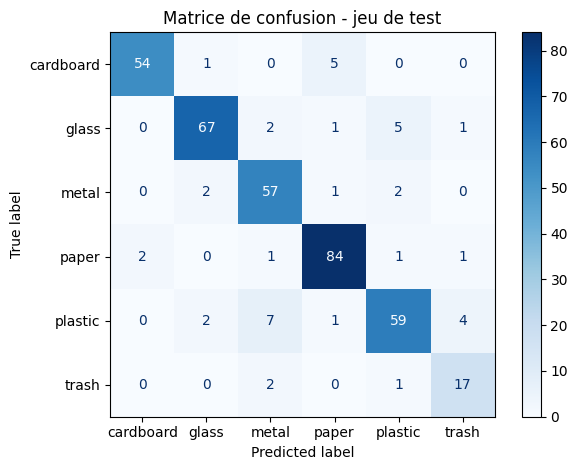

In [12]:
# J'affiche la matrice de confusion pour analyser les erreurs par classe
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

plt.figure(figsize=(10, 10))
disp.plot(cmap='Blues', values_format='d')
plt.title('Matrice de confusion - jeu de test')
plt.tight_layout()
plt.show()

## 7. Sauvegarde du modele et des classes

In [13]:
# Je sauvegarde la liste des classes dans un fichier JSON pour l'inference
classes_list = le.classes_.tolist()
classes_path = os.path.join(base_dir, 'modeles', 'classes_cnn.json')
os.makedirs(os.path.dirname(classes_path), exist_ok=True)

with open(classes_path, 'w', encoding='utf-8') as f:
    json.dump(classes_list, f, ensure_ascii=False, indent=2)

print(f"Modele sauvegarde : {os.path.abspath(best_model_path)}")
print(f"Classes sauvegardees : {os.path.abspath(classes_path)}")
print(f"Classes : {classes_list}")
print("Sauvegarde terminee.")

Modele sauvegarde : D:\_Projet Vision Artificielle\modeles\best_cnn_model.pth
Classes sauvegardees : D:\_Projet Vision Artificielle\modeles\classes_cnn.json
Classes : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Sauvegarde terminee.


---

**Conclusion**

L'entrainement est termine. Les fichiers suivants ont ete generes :
- `modeles/best_cnn_model.pth` : poids du meilleur modele
- `modeles/classes_cnn.json` : liste des classes pour l'inference